## Predição da potabilidade da água a partir dos dados físico-químicos

In [55]:
import tensorflow as tf
import numpy as np
import pandas as pd
import math
import sklearn
import scikeras
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn

In [56]:
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

#### Leitura da base de dados

In [57]:
base = pd.read_csv('data/Watera.csv')

#### Heatmap das correlações entre features

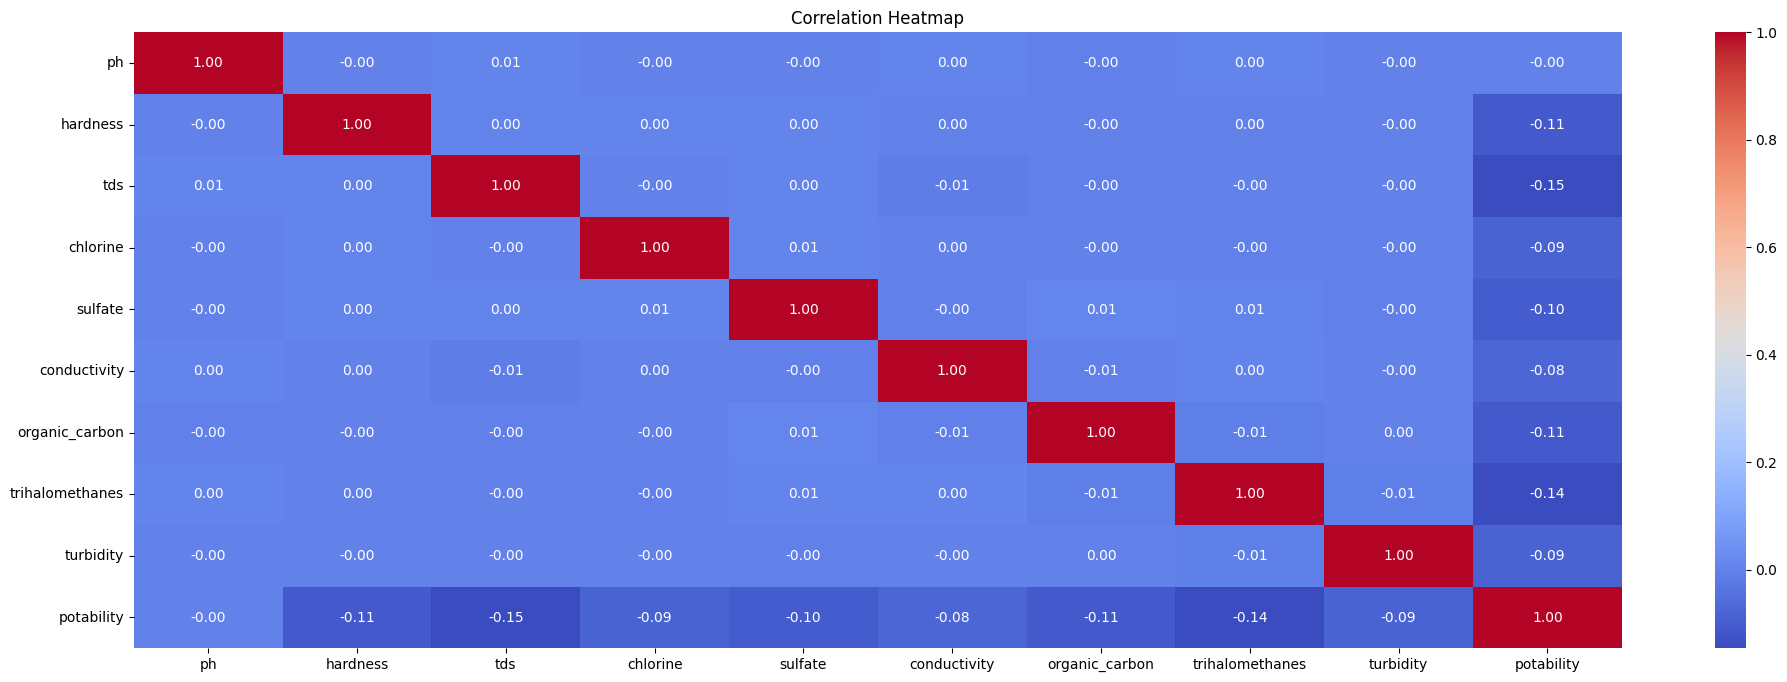

In [58]:
plt.figure(figsize=(24, 8))
sns.heatmap(base.corr(numeric_only=True), annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Análise de outliers no dataset

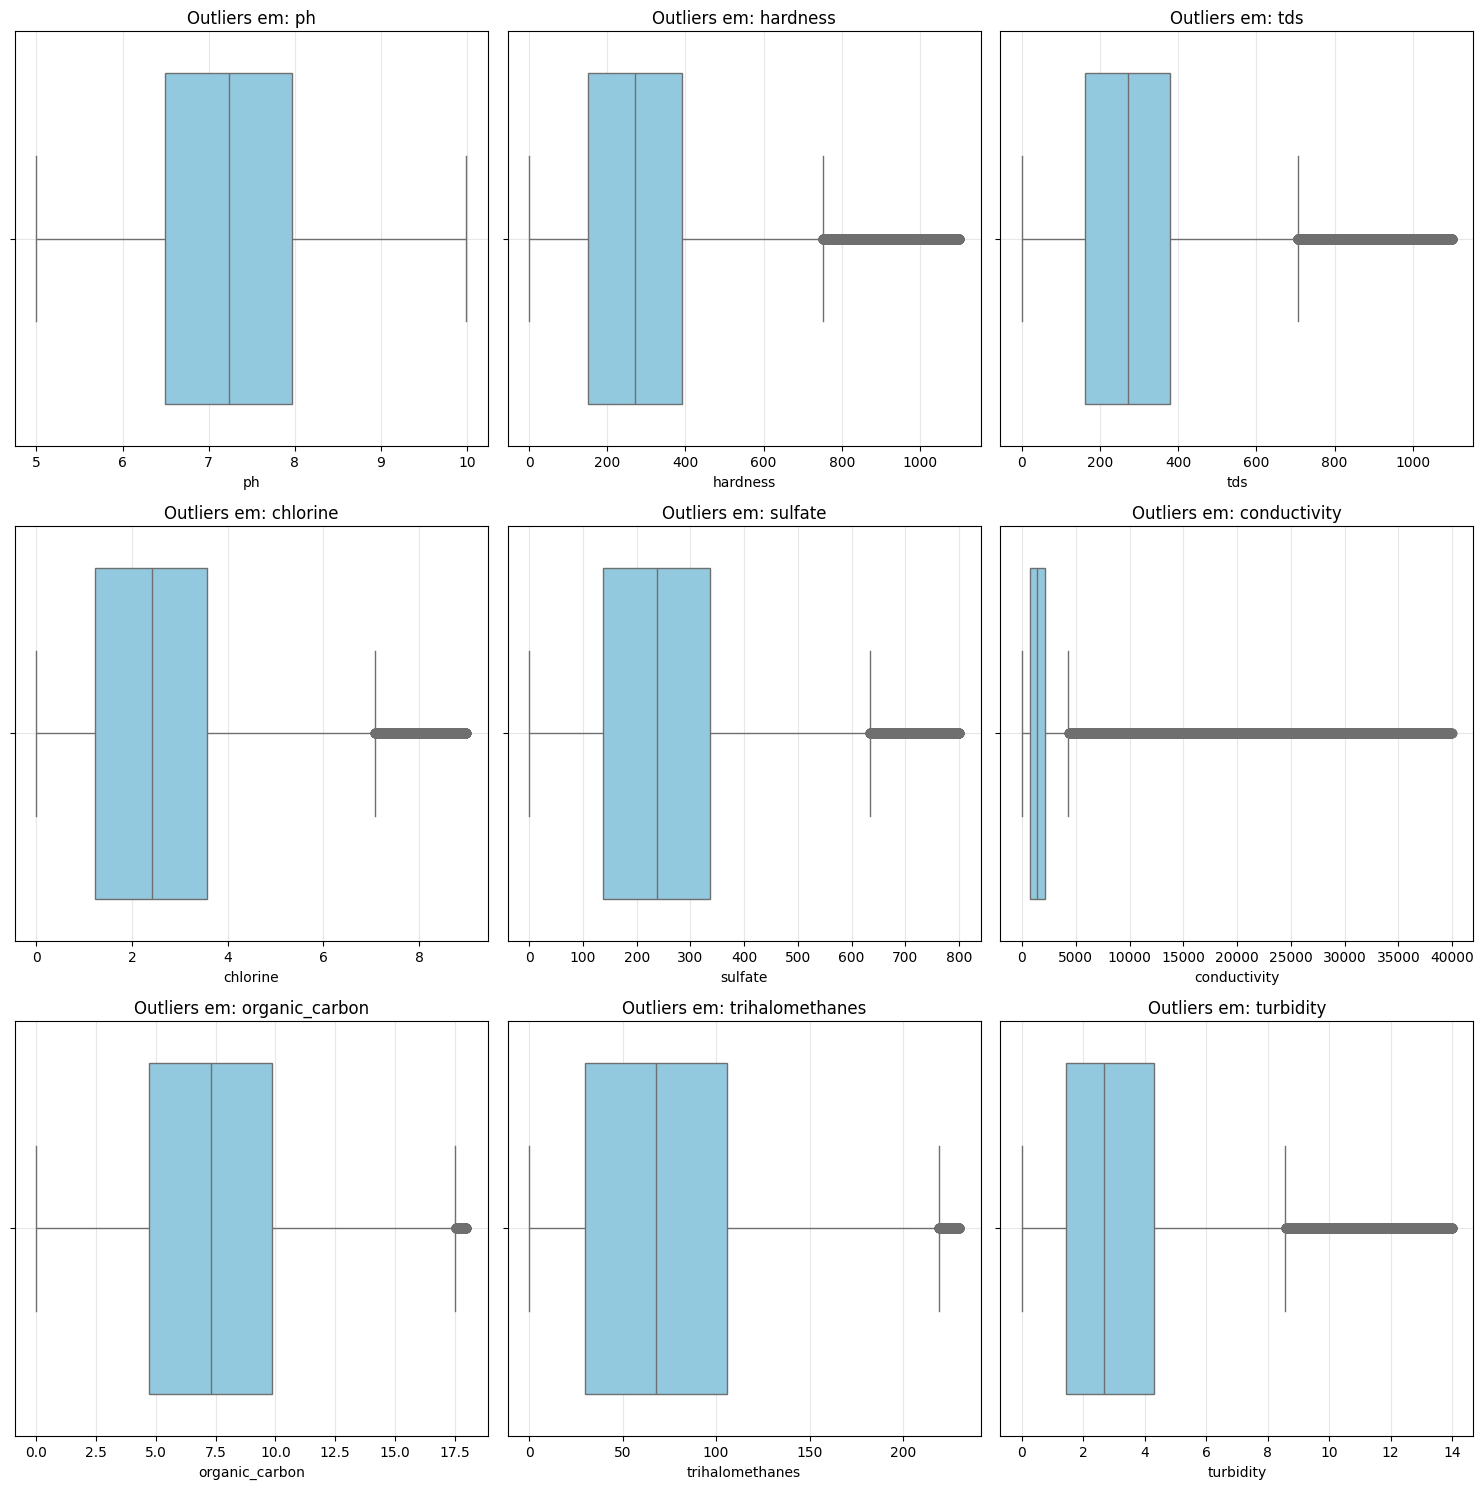

In [59]:
features = base.select_dtypes(include=['number']).columns.drop('potability', errors='ignore')

colunas_linha = 3
linhas = math.ceil(len(features) / colunas_linha)

plt.figure(figsize=(15, 5 * linhas))
for i, col in enumerate(features):
    plt.subplot(linhas, colunas_linha, i + 1)
    sns.boxplot(x=base[col], color='skyblue') 
    plt.title(f'Outliers em: {col}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Remoção dos outliers usando IQR * 1.5

In [60]:
cols_num = base.select_dtypes(include=['number']).columns.drop('potability')

Q1 = base[cols_num].quantile(0.25)
Q3 = base[cols_num].quantile(0.75)
IQR = Q3 - Q1

base_sem_outliers = base[~((base[cols_num] < (Q1 - 1.5 * IQR)) | (base[cols_num] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

total_antes = base.shape[0]
total_depois = base_sem_outliers.shape[0]
perda = total_antes - total_depois

print(f"Linhas originais: {total_antes}")
print(f"Linhas restantes: {total_depois}")
print(f"Dados perdidos: {perda} ({perda/total_antes:.1%})")

Linhas originais: 100000
Linhas restantes: 71499
Dados perdidos: 28501 (28.5%)


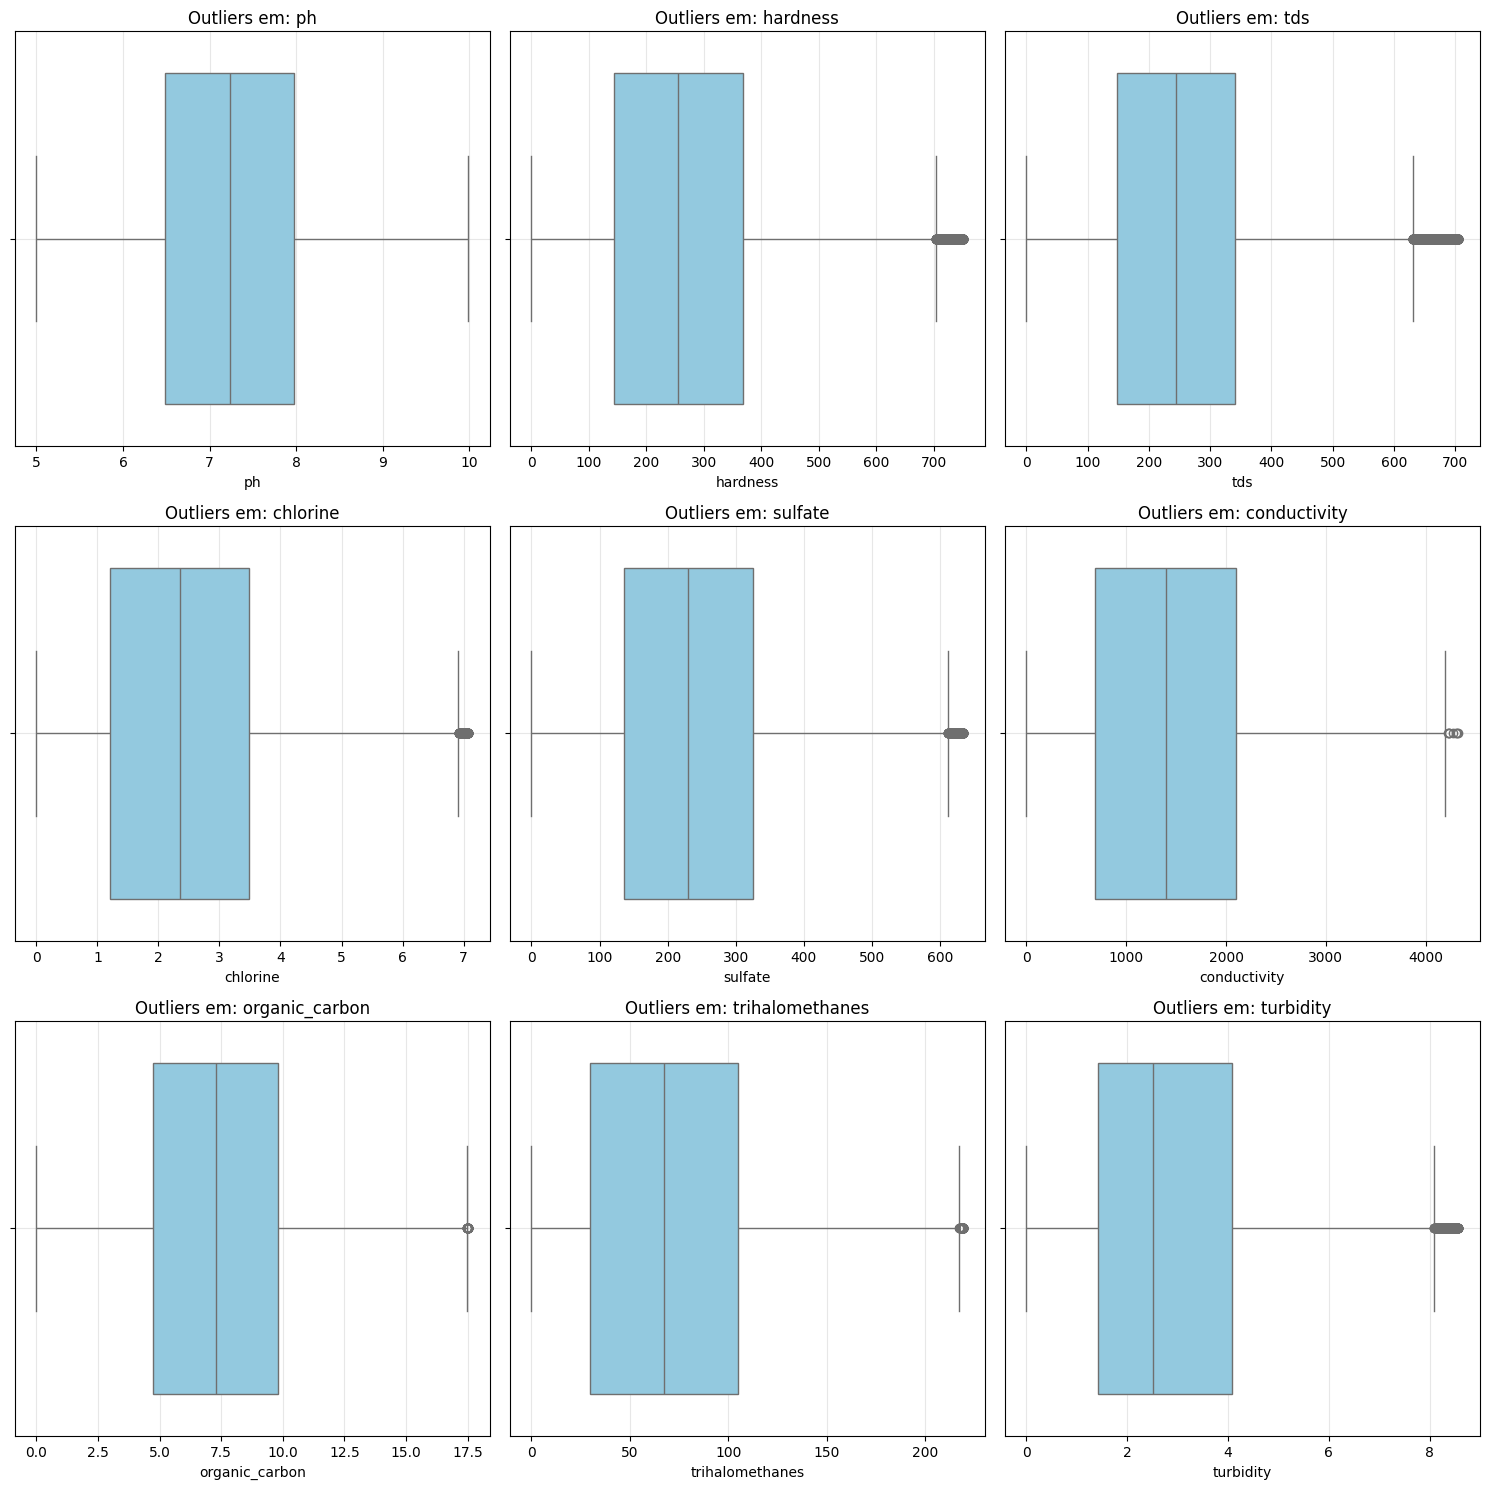

In [61]:
features = base_sem_outliers.select_dtypes(include=['number']).columns.drop('potability', errors='ignore')

colunas_linha = 3
linhas = math.ceil(len(features) / colunas_linha)

plt.figure(figsize=(15, 5 * linhas))
for i, col in enumerate(features):
    plt.subplot(linhas, colunas_linha, i + 1)
    sns.boxplot(x=base_sem_outliers[col], color='skyblue') 
    plt.title(f'Outliers em: {col}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Aplicação do RobustScaler para fazer o escalonamento do dataset resistentes aos outliers

Como o RobustScaler usa métricas que são muito pouco afetadas por outliers (mediana e IQR), matematicamente os outliers são ignorados no escalonamento do dataset

/tmp/ipykernel_58917/3928090252.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


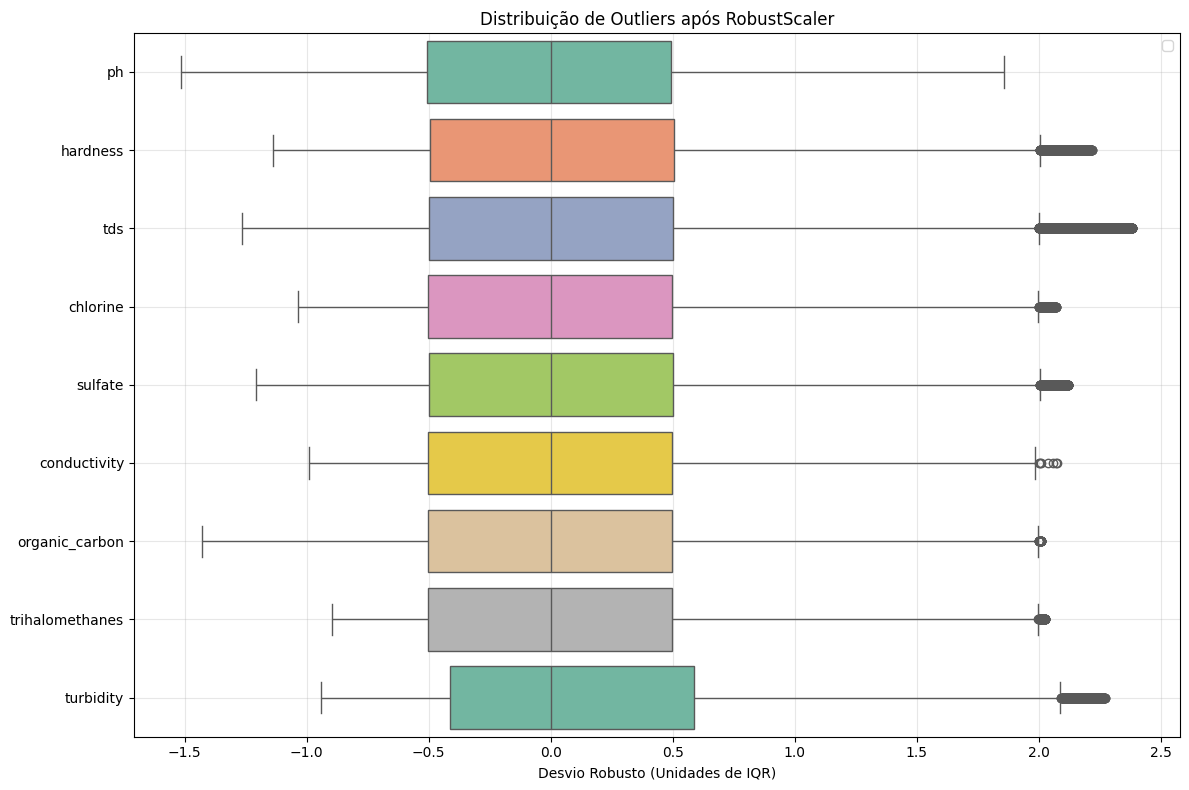

In [62]:
cols_numericas = base_sem_outliers.select_dtypes(include=['number']).columns.drop('potability', errors='ignore')

scaler = RobustScaler()
base_escalada = pd.DataFrame(scaler.fit_transform(base_sem_outliers[cols_numericas]), 
                           columns=cols_numericas)

plt.figure(figsize=(12, 8))
sns.boxplot(data=base_escalada, orient='h', palette="Set2")
plt.title('Distribuição de Outliers após RobustScaler')
plt.xlabel('Desvio Robusto (Unidades de IQR)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Tratamento dos valores nulos do dataset

In [63]:
base_sem_outliers.shape

(71499, 10)

In [64]:
base_sem_outliers.isnull().sum()

ph                 2219
hardness              0
tds                1939
chlorine              0
sulfate             603
conductivity       1173
organic_carbon        0
trihalomethanes       0
turbidity             0
potability            0
dtype: int64

In [65]:
base_sem_outliers['ph'] = base_sem_outliers['ph'].fillna(value=base_sem_outliers['ph'].median())
base_sem_outliers['tds'] = base_sem_outliers['tds'].fillna(value=base_sem_outliers['tds'].median())
base_sem_outliers['sulfate'] = base_sem_outliers['sulfate'].fillna(value=base_sem_outliers['sulfate'].median())
base_sem_outliers['conductivity'] = base_sem_outliers['conductivity'].fillna(value=base_sem_outliers['conductivity'].median())

In [66]:
base_sem_outliers.isnull().sum()

ph                 0
hardness           0
tds                0
chlorine           0
sulfate            0
conductivity       0
organic_carbon     0
trihalomethanes    0
turbidity          0
potability         0
dtype: int64

#### Análise das correlações após imputação de valores para preencher os valores faltantes

<Axes: >

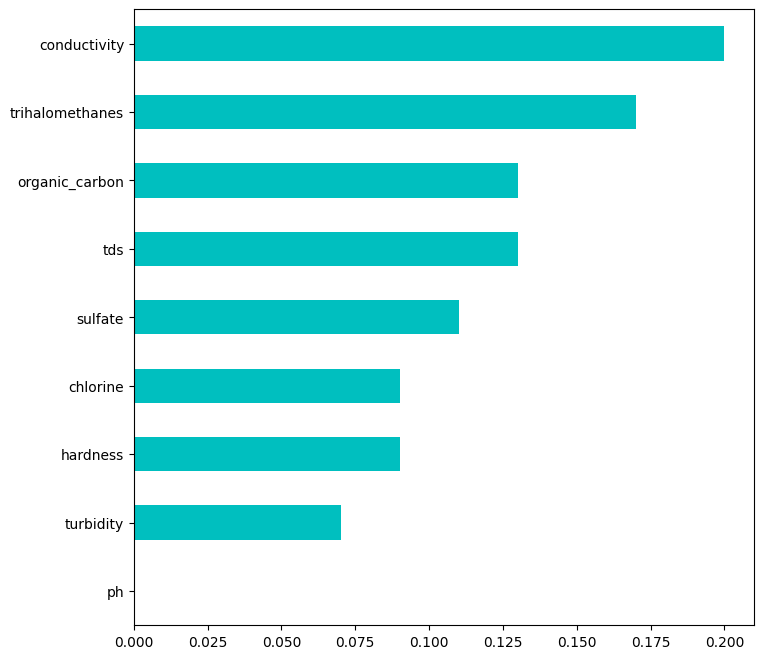

In [67]:
fig,ax = plt.subplots(figsize=(8,8))
abs(base_sem_outliers.corr().round(2)['potability']).sort_values()[:-1].plot.barh(color='c')

In [68]:
X = base_sem_outliers.drop(columns=['potability'])
y = base_sem_outliers['potability']

In [69]:
X.shape, y.shape

((71499, 9), (71499,))

#### Análise da distribuição dos rótulos no dataset

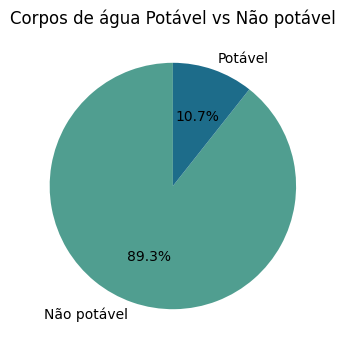

In [70]:
potability = base_sem_outliers['potability'].value_counts(normalize = True)
plt.figure(figsize = (4,4))
plt.pie(potability, labels = ['Não potável', 'Potável'], autopct = '%1.1f%%', startangle =90, colors=sns.color_palette("crest", 2))
plt.title('Corpos de água Potável vs Não potável')
plt.show()

#### Divisão dos dados

In [71]:
X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(X, y, test_size=0.15, random_state=7)

In [72]:
X_treino, X_val, y_treino, y_val = train_test_split(X_treino_val, y_treino_val, test_size=0.176, random_state=7)

In [73]:
X_treino.shape, X_val.shape, X_teste.shape, y_treino.shape, y_val.shape, y_teste.shape

((50077, 9), (10697, 9), (10725, 9), (50077,), (10697,), (10725,))

#### Aplicação do SMOTE para geração de dados sintéticos para a classe minoritária

In [74]:
smote = SMOTE(random_state=7)
X_treino_bal, y_treino_bal = smote.fit_resample(X_treino, y_treino)

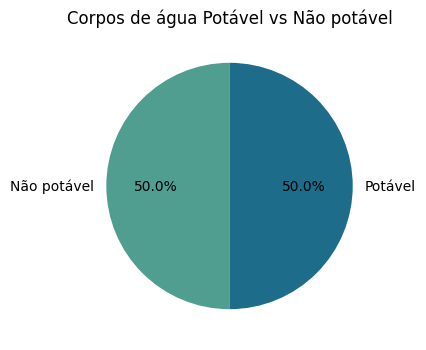

In [75]:
potability = y_treino_bal.value_counts(normalize = True)
plt.figure(figsize = (4,4))
plt.pie(potability, labels = ['Não potável', 'Potável'], autopct = '%1.1f%%', startangle =90, colors=sns.color_palette("crest", 2))
plt.title('Corpos de água Potável vs Não potável')
plt.show()

In [76]:
X_treino_bal.shape, y_treino_bal.shape

((89554, 9), (89554,))

#### Aplicação do Scaler nos dados

In [77]:
scaler = RobustScaler()

In [78]:
X_treino_prep = scaler.fit_transform(X_treino_bal)
X_val_prep = scaler.transform(X_val)
X_teste_prep = scaler.transform(X_teste)

In [79]:
X_treino_prep.shape, X_val_prep.shape, X_teste_prep.shape

((89554, 9), (10697, 9), (10725, 9))

#### Tuning dos hiper-parâmetros

In [80]:
def criar_modelo(neurons, drop_rate, num_camadas, activation):
   classificador = Sequential()
   classificador.add(Input(shape=(9,)))

   for _ in range(num_camadas):
      classificador.add(Dense(units=neurons, activation=activation))
      classificador.add(Dropout(rate=drop_rate))
   
   classificador.add(Dense(units=1, activation='sigmoid'))
   return classificador

In [81]:
param_grid = {
    'batch_size': [64, 128],
    'model__neurons': [32, 64],
    'model__num_camadas': [2, 3, 4],
    'model__drop_rate': [0.1, 0.2],
    'optimizer__learning_rate': [0.01, 0.001],
    'model__activation': ['relu', 'elu']
}
# 2 * 2 * 3 * 2 * 2 * 2 = 96 combinacoes

In [82]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=15,
    restore_best_weights=True
)

In [83]:
classificador = KerasClassifier(
    model=criar_modelo,
    loss='binary_crossentropy',
    metrics=['accuracy'],
    callbacks=[early_stop],
    epochs=100,
    validation_split=0.17,
    random_state=7,
    optimizer='adam'
)

In [84]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=7)),
    ('scaler', RobustScaler()),
    ('model', classificador)
])

In [85]:
# grid_search = GridSearchCV(
# 	estimator=pipeline,
# 	param_grid=param_grid,
# 	scoring='accuracy',
# 	cv=5,
# 	n_jobs=1
# )
# # media de 30 epochs até stop, media de 0.3s por epoch
# # 30 * 0.3s = 9s
# # 9s * 5 folds * 96 comb = 4320s = 72min

In [86]:
# grid_search.fit(X_treino_val, y_treino_val)

In [87]:
# print(f"Melhor Score (Erro): {grid_search.best_score_}") 
# print(f"Melhores Parâmetros: {grid_search.best_params_}")

#### Utilização do modelo com os melhores hiperparâmetros encontrados

In [88]:
def criar_modelo():
   classificador = Sequential([
      Input(shape=(9,)),
      Dense(units=64, activation='elu'),
      Dropout(rate=0.2),

      Dense(units=48, activation='elu'),
      BatchNormalization(),
      Dropout(rate=0.2),

      Dense(units=1, activation='sigmoid')
   ])
   return classificador

In [89]:
otimizador = Adam(learning_rate=0.01)

In [90]:
classificador = KerasClassifier(
    model=criar_modelo,
    loss='binary_crossentropy',
    metrics=['accuracy'],
    callbacks=[early_stop],
    batch_size=64,
    epochs=100,
    optimizer=otimizador
)

In [91]:
historico = classificador.fit(X_treino_prep, y_treino_bal, validation_data=(X_val_prep, y_val))

Epoch 1/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8920 - loss: 0.2594 - val_accuracy: 0.9188 - val_loss: 0.1758
Epoch 2/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9285 - loss: 0.1870 - val_accuracy: 0.9213 - val_loss: 0.1666
Epoch 3/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9398 - loss: 0.1624 - val_accuracy: 0.9204 - val_loss: 0.1821
Epoch 4/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9444 - loss: 0.1532 - val_accuracy: 0.9462 - val_loss: 0.1287
Epoch 5/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9502 - loss: 0.1410 - val_accuracy: 0.9554 - val_loss: 0.1069
Epoch 6/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9530 - loss: 0.1336 - val_accuracy: 0.9319 - val_loss: 0.1612
Epoch 7/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9557 - loss: 0.1271 - val_accuracy: 0.9570 - val_loss: 0.1065
Epoch 8/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9570 - loss: 0

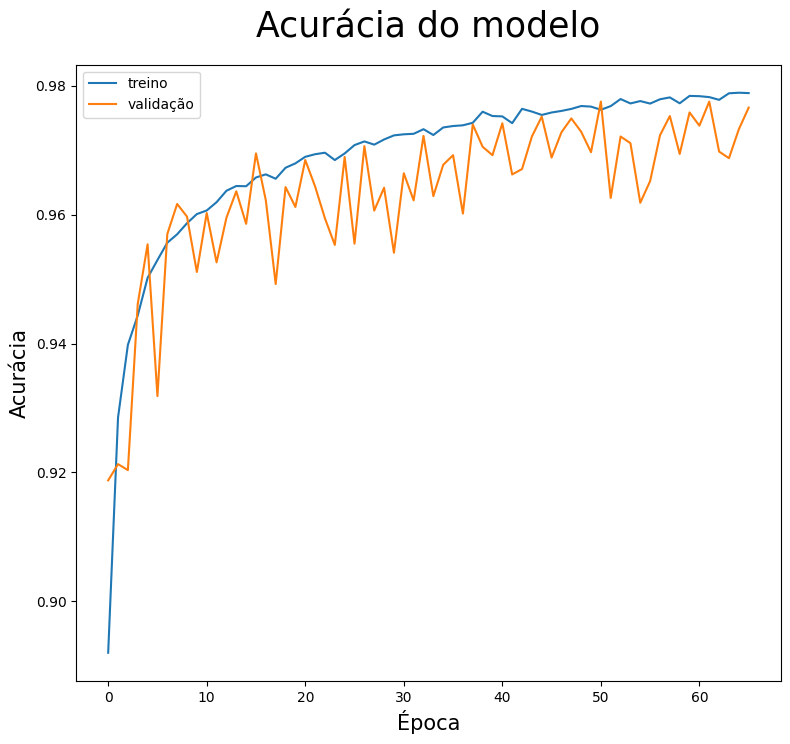

In [92]:
plt.figure(figsize=[20,8])

plt.subplot(1,2,1)
plt.plot(historico.history_['accuracy'])
plt.plot(historico.history_['val_accuracy'])
plt.title('Acurácia do modelo', size=25, pad=20)
plt.ylabel('Acurácia', size=15)
plt.xlabel('Época', size=15)
plt.legend(['treino', 'validação'], loc='upper left')

In [93]:
y_pred = classificador.predict(X_teste_prep)

168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step


In [94]:
print("Relatório de Classificação:")
print(classification_report(y_teste, y_pred, target_names=['Não Potável', 'Potável']))

Relatório de Classificação:
              precision    recall  f1-score   support

 Não Potável       0.99      0.99      0.99      9576
     Potável       0.88      0.90      0.89      1149

    accuracy                           0.98     10725
   macro avg       0.93      0.94      0.94     10725
weighted avg       0.98      0.98      0.98     10725



In [95]:
cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Potável', 'Potável'])

<Figure size 600x600 with 0 Axes>

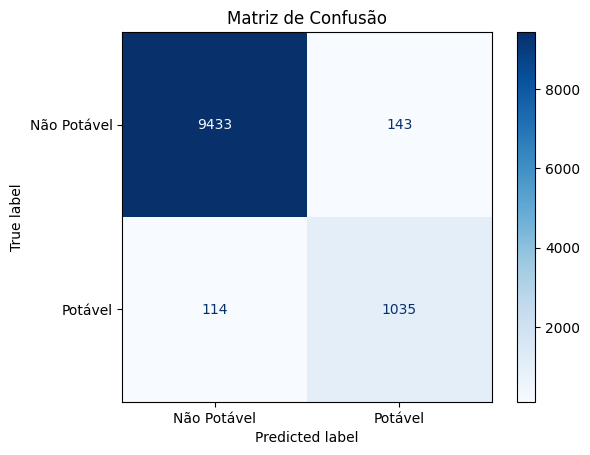

In [96]:
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão')
plt.show()

#### Salvando o modelo

In [97]:
classificador_treinado = classificador.model_

In [98]:
classificador_treinado.save("models/classifier.keras")